# Import Library & Load Data

In [ ]:
# import library yang diperlukan
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



Dataset: https://archive.ics.uci.edu/dataset/352/online+retail

In [ ]:
# Load data
df = pd.read_excel('Online Retail.xlsx')

# Initial EDA

Lakukan beberapa hal sebagai langkah eksplorasi awal! Misal, melihat informasi atau struktur data, mengecek jumlah null, melihat deskripsi statistik

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# cek persentase null tiap kolom
df.isnull().sum() / df.shape[0] * 100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df[(df['Quantity'] < 0) | (df['UnitPrice'] < 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


# Data Preprocessing

Lakukan data cleaning, filtering, feature engineering, dan standardisasi

In [ ]:
# Data cleaning
# Drop missing customer ID
df = df.dropna(subset=['CustomerID'])

# Filter transaksi yang valid: quantity >0 , unitprice > 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df.shape



(397884, 8)

In [ ]:
df['InvoiceNo'].nunique()

18532

In [ ]:
df['InvoiceNo'].count()

np.int64(397884)

In [ ]:
# Buat kolom TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Hitung RFM: Recency, Frequency, Monetary
# gunakan snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # recency
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']



In [ ]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [ ]:
rfm_2 = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # recency
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm_2.columns = ['Recency', 'Frequency', 'Monetary']


In [ ]:
# Lakukan standardisasi!
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency', 'Monetary']])

In [ ]:
rfm_scaled

array([[ 2.33457414e+00, -4.25096503e-01,  8.35866818e+00],
       [-9.05340320e-01,  3.54416797e-01,  2.50966264e-01],
       [-1.75359593e-01, -3.53398530e-02, -2.85960063e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08742313e-01],
       [-8.85340848e-01,  1.52368675e+00,  4.51854273e-03],
       [-4.95351144e-01, -1.65258736e-01, -2.41412739e-02]])

# Clustering

## Mencari nilai K optimal

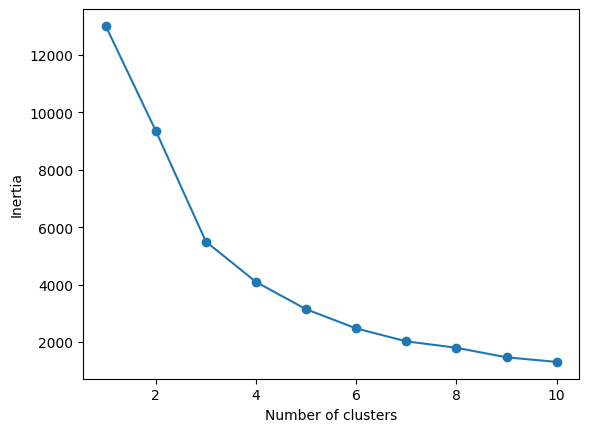

In [ ]:
# Elbow method untuk cari jumlah cluster optimal
inertia = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

# membuat scree plot (elbow method)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


Berdasarkan elbow method, mungkin clusternya 4? Antara 3-5.

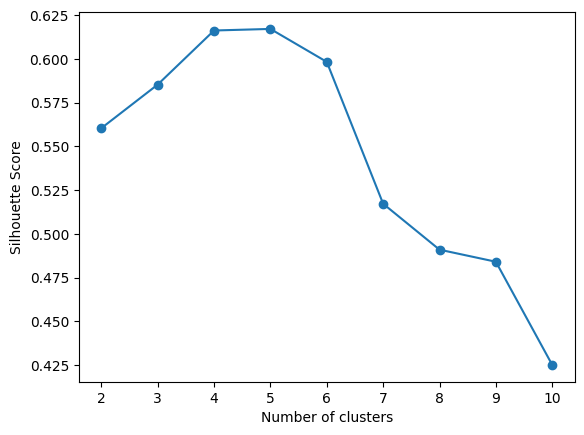

In [ ]:
# Silhouette score

ss = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(rfm_scaled)
  ss.append(silhouette_score(rfm_scaled, labels))

plt.plot(range(2,11), ss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [ ]:
ss

[np.float64(0.5603671809121974),
 np.float64(0.5852924318247733),
 np.float64(0.616212846765192),
 np.float64(0.617115186725246),
 np.float64(0.5982715957283189),
 np.float64(0.51717221452567),
 np.float64(0.49091567183009177),
 np.float64(0.484017028247486),
 np.float64(0.42503454870703994)]

Kira-kira berapa jumlah cluster yang dipilih?

## Fit model kmeans

Fit model sesuai jumlah cluster yang dipilih

In [ ]:
# Fit kmeans clustering berdasarkan jumlah cluster yang dipilih
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# masukkan hasil cluster sebagai kolom pada dataframe/dataset
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## Visualisasi (opsional)

Kamu bisa membuat visualisasi. Karena RFM ada 3 komponen, maka bisa visualisasi 3D atau lakukan PCA dahulu untuk visualisasi 2D

In [ ]:
# Visualisasi hasil clustering
# PCA untuk reduksi dimensi ke 2D



In [ ]:
# Visualisasi 3D
from mpl_toolkits.mplot3d import Axes3D



## Interpretasi

Melihat karakteristik dari setiap cluster. Kamu bisa melihat berdasarkan deskripsi statistik, melihat distrbusi, dan sebagainya.

In [ ]:
rfm.groupby('Cluster').describe().T

Cluster                     0            1              2             3
Recency   count   3054.000000  1067.000000      13.000000    204.000000
          mean      43.702685   248.075914       7.384615     15.500000
          std       35.966256    66.330522      11.485777     40.924116
          min        1.000000   143.000000       1.000000      1.000000
          25%       15.000000   190.000000       1.000000      2.750000
          50%       32.000000   243.000000       2.000000      5.000000
          75%       65.000000   299.000000       8.000000     14.250000
          max      163.000000   374.000000      39.000000    372.000000
Frequency count   3054.000000  1067.000000      13.000000    204.000000
          mean       3.682711     1.552015      82.538462     22.333333
          std        2.856518     1.070613      63.264808     11.683286
          min        1.000000     1.000000       2.000000      1.000000
          25%        1.000000     1.000000      46.000000     15.000000
          50%        3.000000     1.000000      63.000000     19.000000
          75%        5.000000     2.000000      97.000000     26.000000
          max       15.000000    12.000000     209.000000     93.000000
Monetary  count   3054.000000  1067.000000      13.000000    204.000000
          mean    1359.049284   480.617480  127338.313846  12709.090490
          std     1542.732124   638.698818   79723.434398  13160.445845
          min        6.200000     3.750000   33719.730000   1296.440000
          25%      384.065000   170.395000   60767.900000   5418.180000
          50%      829.295000   310.470000  117379.630000   8037.730000
          75%     1787.967500   539.630000  168472.500000  13714.137500
          max    21429.390000  9864.260000  280206.020000  77183.600000

Bagaimana interpretasimu berdasarkan karakteristik tiap cluster?

Cluster 0: Mediannya sebulan terakhir ini belanja, spending bottom 2, bottom 2

Cluster 1: Pelanggan yang udah lama banget nggak belanja, sedikit juga belanja

Cluster 2: Customer terbaik! (Spending terbanyak, paling sering belanja, baru-baru ini juga belanjanya)

Cluster 3: Customer di bawah cluster 2 (top 2 dari segala variabel rfm)

In [ ]:
# visualisasi boxplot
